In [257]:
import warnings
warnings.filterwarnings('ignore')

In [258]:
import pandas as pd
import numpy as np
import pyreadr
import joblib
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [259]:
pd.set_option('display.max_columns', 100)

In [260]:
dem_uncont = 34
rep_uncont = 31

In [261]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,53,Democrats
1,54,Democrats
2,46,Republicans
3,54,Democrats
4,47,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,49,Republicans


In [262]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,38,1,0.0125,Republicans
1,39,1,0.0125,Republicans
2,40,2,0.0250,Republicans
3,41,3,0.0375,Republicans
4,42,12,0.1500,Republicans


In [263]:
np.unique(seat_sims['seats']).shape[0]

26

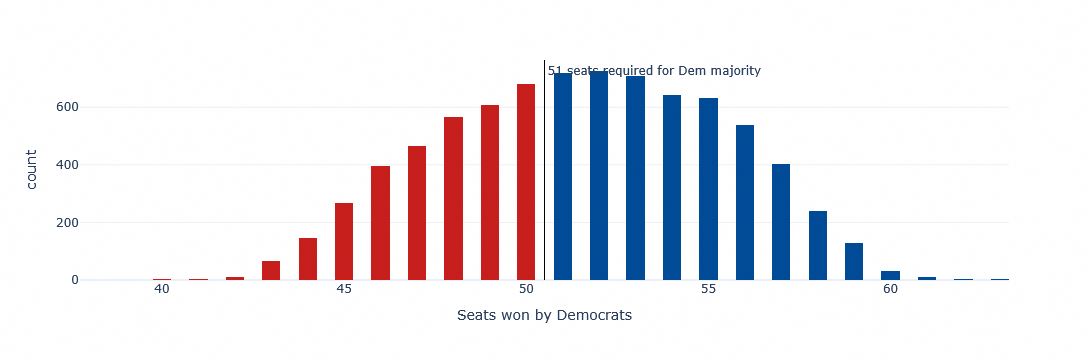

In [264]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [265]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


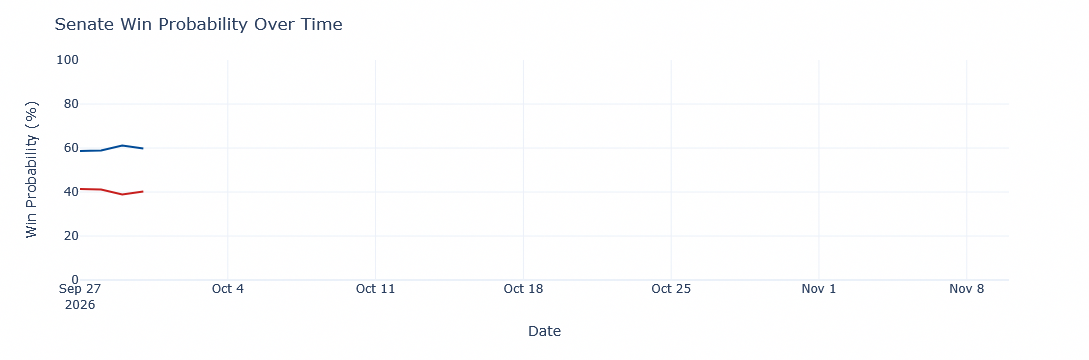

In [266]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="Senate Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

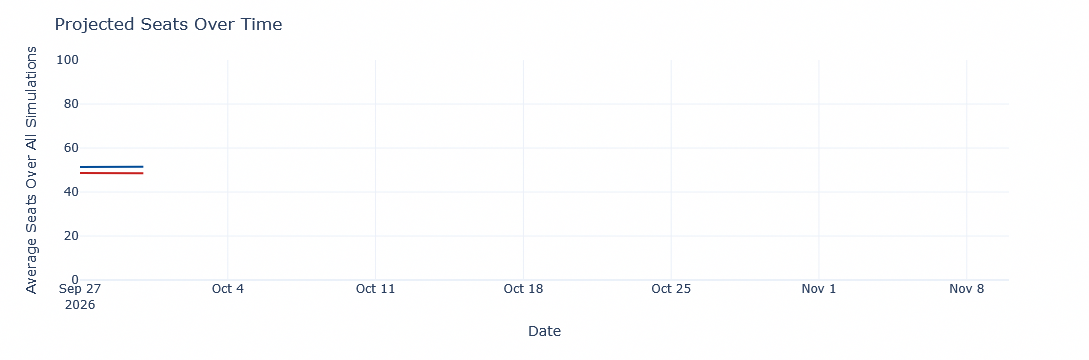

In [267]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [268]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [269]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [270]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.632377,-13.625133,-11.846625,-11.794156,-9.536297,-13.328626,-11.514570,-5.448891,-12.505271,-17.187745,-1.267415,-13.450819,-11.351228,-11.600846,-12.020005,-9.177112,-9.684512,-12.539272,-10.144920,-7.536412,-12.866018,-8.867296,-6.896187,-9.507671,-9.005960,-14.246190,-13.788029,-8.097326,-13.167946,-12.709945,-10.233705,-11.780827,-11.555298,-8.163776,-15.998560,-15.097866,-7.718798,-11.044867,-8.857817,-12.321169,-10.829565,-8.885015,-13.854949,-10.747147,-13.090350,-13.433675,-12.995588,-15.239310,-7.575501,-11.372685,...,-11.653767,-11.020365,-10.148132,-15.033690,-7.326074,-11.597697,-13.077330,-7.904582,-12.413079,-8.116870,-16.249106,-16.233152,-10.626225,-7.282033,-17.577485,-7.022246,-16.427583,-3.008104,-12.474859,-8.636132,-11.774969,-9.995679,-4.343412,-21.552009,-3.116571,-14.657978,-11.972754,-13.346803,-8.265452,-12.333219,-10.963586,-12.595463,-11.083670,-7.944619,-16.694581,-12.514747,-11.099830,-18.644287,-10.494076,-9.781092,-10.891353,-14.312982,-10.682334,-10.359149,-12.141632,-13.250434,-14.950327,-10.229361,-12.620213,-12.223902
AK,0.212158,5.392699,-0.309593,5.298302,-1.191586,4.384158,4.864216,5.312998,-0.779716,-5.831916,10.645261,0.262258,-1.182215,6.346254,-1.099798,2.847663,5.474709,4.459603,-0.617176,2.585823,6.584275,4.157984,2.042293,4.944316,4.482156,1.223885,2.182232,3.228198,-1.121624,1.407646,3.232196,5.371427,6.826720,8.172705,2.599048,-0.384110,3.227089,-0.055270,-1.185638,2.772848,-1.309165,3.363370,6.759189,3.945324,2.485293,-1.828910,0.795717,2.827146,1.854390,4.096842,...,3.860500,2.652318,9.752626,-0.664016,7.282242,2.571805,1.064312,3.397592,-1.645630,10.239880,2.081240,-1.212693,6.772740,3.053886,3.654940,1.229206,4.824542,1.760067,-0.890156,7.208453,1.337323,2.993118,8.240400,-0.148735,3.871337,-2.563655,6.076682,4.722453,3.222829,0.746953,-3.456230,5.049264,-0.988803,5.689266,1.507816,2.789280,3.065257,7.021680,3.775100,3.692405,-0.061576,4.053071,3.754425,-0.012982,3.748154,0.584811,1.553704,0.406827,3.186949,1.412907
AR,-11.197729,-12.974653,-9.360410,-12.038174,-10.828326,-9.030634,-10.083639,-6.638562,-15.237601,-14.987120,-2.190625,-12.740804,-13.601011,-8.116691,-13.083411,-11.727379,-11.059954,-9.559083,-11.919014,-8.264019,-12.247603,-11.718719,-8.031483,-8.200144,-12.431054,-9.850965,-12.280351,-8.912653,-12.260241,-12.051510,-9.409809,-10.125076,-7.544525,-8.306659,-14.479518,-13.942592,-7.205946,-10.747680,-12.263626,-11.335045,-11.394251,-7.273149,-13.080948,-14.920343,-13.560337,-11.768275,-9.892935,-14.864535,-11.760058,-12.730043,...,-13.776631,-12.384446,-9.018507,-14.377710,-4.759771,-13.230960,-13.608104,-12.338740,-11.185827,-4.897594,-15.524290,-13.109105,-9.131760,-8.488051,-14.429082,-5.615484,-16.402452,-2.087709,-10.216738,-9.491460,-12.747106,-7.270729,-5.807227,-16.414510,-4.270932,-17.393896,-10.059537,-17.077094,-6.194683,-10.682835,-10.080740,-11.805656,-10.531270,-3.394029,-18.447904,-10.560890,-8.598883,-13.348907,-6.956638,-13.024979,-12.072608,-11.630602,-9.528640,-8.056732,-12.224047,-14.261506,-17.911562,-12.180234,-8.616865,-11.701678
CO,11.547146,12.328756,7.402191,14.253669,9.008116,12.691409,14.493630,13.384773,10.959094,7.284660,13.452081,13.939391,11.055785,16.318684,8.068993,15.799939,13.856737,11.941611,6.952665,6.220348,13.079191,18.836851,10.042850,16.578283,13.830352,11.624952,11.451148,20.201290,7.868125,13.664993,14.224235,10.605918,9.522720,10.626537,11.908130,5.954646,16.462104,11.349500,15.566455,9.352284,13.196821,12.175792,11.807990,13.745354,10.741911,11.878553,7.796172,11.260741,12.538567,9.681863,...,13.955801,8.785333,17.558322,

In [271]:
sim_corr = post_untransp.corr()

In [272]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.519396,0.740542,0.489758,0.497614,0.706743,0.532909,0.737643,0.709012,0.745082,0.740096,0.541600,0.752411,0.739400,0.523767,0.735672,0.709383,0.744309,0.701277,0.727081,0.505740,0.506818,0.509910,0.707668,0.508486,0.758780,0.508379,0.492624,0.493052,0.513906,0.559373,0.704834,0.506790,0.742030,0.739768
AK,0.519396,1.000000,0.517316,0.522339,0.525638,0.501096,0.559650,0.526539,0.503787,0.518263,0.518211,0.566349,0.524499,0.511594,0.561201,0.512280,0.499843,0.517839,0.498288,0.515239,0.561237,0.539754,0.553680,0.497712,0.551687,0.521277,0.547492,0.549578,0.537822,0.541427,0.597549,0.507318,0.544816,0.520862,0.519561
AR,0.740542,0.517316,1.000000,0.487454,0.500012,0.703810,0.527700,0.736840,0.700066,0.741725,0.738097,0.537264,0.742272,0.732185,0.523410,0.729211,0.700228,0.725899,0.693051,0.721754,0.509334,0.500544,0.502743,0.705376,0.504688,0.744338,0.501875,0.496687,0.495615,0.515360,0.557049,0.702293,0.498877,0.735937,0.735114
CO,0.489758,0.522339,0.487454,1.000000,0.708954,0.654256,0.550555,0.498039,0.655189,0.503369,0.488279,0.549448,0.503983,0.486825,0.537780,0.487338,0.642588,0.493844,0.652800,0.478010,0.711115,0.715794,0.720404,0.647366,0.706259,0.499966,0.710489,0.702197,0.699319,0.530589,0.571428,0.656201,0.703961,0.496862,0.494060
DE,0.497614,0.525638,0.500012,0.708954,1.000000,0.667668,0.543105,0.504848,0.665176,0.508847,0.499977,0.547751,0.503507,0.502054,0.548859,0.501744,0.663123,0.499252,0.663558,0.489588,0.719016,0.725937,0.729507,0.661325,0.715962,0.515659,0.710037,0.712554,0.709596,0.521094,0.577944,0.661768,0.719021,0.499428,0.509314


In [273]:
post.shape

(35, 8000)

In [274]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [275]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:05<00:00, 1406.74it/s]


array(['IA', 'MI', 'TX', ..., 'IA', 'TX', 'AK'],
      shape=(8000,), dtype='<U32')

In [276]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.047141,47.730058,1,95.460117,61.901210,3.504030,99.9625,4,55.112867,68.805422
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.140394,48.524126,1,97.048252,63.444437,3.504475,99.9875,5,56.605592,70.401143


In [277]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.6750
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.047141,47.730058,1,95.460117,61.901210,3.504030,99.9625,4,55.112867,68.805422,0.1125
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.140394,48.524126,1,97.048252,63.444437,3.504475,99.9875,5,56.605592,70.401143,0.7000


In [278]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-9.118005,0,0,47.705186,8.542550,44.669411,8.542550,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,8.542550,2.922764,-3.035775,8.733093,17.834942,0,35.669884,50.860328,3.538050,59.4375,16,44.085618,57.854433,11.0875
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-9.118005,0,0,47.806278,6.684858,45.272008,6.684858,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,6.684858,2.585509,-2.534270,-2.715743,37.909568,0,75.819136,51.021679,3.627800,61.0875,32,43.924572,58.218366,10.7750
13,13,Maine,Troy Jackson,Susan Collins,False,True,R,ME,no_match,"COLLINS, SUSAN M.",0.00,10501136.60,10501136.60,0.000000,100.000000,3.820912,53.544306,94.249770,0.897865,1.689465,0.930085,0.342309,36.189622,526309,836050,1362359,38.632181,61.367819,0.987401,-9.118005,0,1,48.007447,4.132086,45.913710,4.132086,New England,2026,0.0,0.00000,0.00000,3,Senate,0.000000,4.132086,2.032753,-2.093737,16.759829,-50.000000,-1,-100.000000,50.195166,3.582791,51.7000,14,43.092638,57.265559,10.1000
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-9.118005,0,0,46.337185,5.039152,45.836367,5.039152,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,5.039152,2.244806,-0.500818,-3.067662,2.558612,0,5.117224,49.661607,3.515186,45.4000,10,42.670981,56.540348,9.2250
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-9.118005,0,1,48.771885,2.244733,43.407525,2.244733,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,2.244733,1.498243,-5.364360,-1.415103,33.220254,-1,66.440509,51.204668,3.466019,63.9375,25,44.274541,58.072567,8.4125


In [279]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [280]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.6750,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.047141,47.730058,1,95.460117,61.901210,3.504030,99.9625,4,55.112867,68.805422,0.1125,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.118005,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.140394,48.524126,1,97.048252,63.444437,3.504475,99.9875,5,56.605592,70.401143,0.7000,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [281]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [282]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [283]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.1
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.8
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.5


In [284]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.1,99.9375,0.1,99.9,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.8,19.3000,80.7,19.3,80.7%,19.3%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.5,99.8750,0.1,99.9,<1%,>99%


In [285]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.1,99.9375,0.1,99.9,<1%,>99%,8.809322
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.8,19.3000,80.7,19.3,80.7%,19.3%,19.536690
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.118005,0,1,38.189521,0.432740,49.190029,0.432740,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.432740,0.657830,11.000508,-21.503038,-8.541719,-1,-17.083438,39.233596,3.568249,0.1250,3,32.133608,46.132808,0.000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.5,99.8750,0.1,99.9,<1%,>99%,9.807178


In [286]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.118005,0,0,32.000000,0.047044,47.000000,0.047044,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.047044,0.216896,15.000000,-20.508437,-49.622498,0,-99.244996,38.964049,3.537243,0.0625,1,32.155306,46.034290,0.000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.1,99.9375,0.1,99.9,<1%,>99%,8.809322,D+8.8
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.118005,0,1,49.473113,2.033410,48.488694,2.033410,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.033410,1.425977,-0.984419,-3.792600,49.948144,-1,99.896288,52.921783,3.399676,80.7000,2,46.265758,59.697069,5.675,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.8,19.3000,80.7,19.3,80.7%,19.3%,19.536690,D+19.5


In [287]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.1,D+8.8,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">80.7%</p>","<p style=""color:red;"">19.3%</p>",D+5.8,D+19.5,5.6750
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.5,D+9.8,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.8,D+12.5,0.1125
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+26.9,D+11.9,0.7000


In [288]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

7.3973487562821045

In [289]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.510500
1,chamber_win_chance,59.800000
0,sv_bias,7.397349


In [290]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [291]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,59.8,51.5105
1,Republicans,40.2,48.4895


In [292]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [293]:
rating_ts = output_ts[output_ts['type'] == 'chance']
rating_ts['rating'] = rating_ts['y'].map(get_rating)
rating_ts['date'] = pd.to_datetime(rating_ts['date'])
rating_ts.head()

,date,y,geo,type,rating
1,2026-09-27,58.6000,US Senate,chance,Tossup
5,2026-09-27,0.0500,AL,chance,Safe R
10,2026-09-27,79.8875,AK,chance,Likely D
15,2026-09-27,0.1250,AR,chance,Safe R
20,2026-09-27,99.9625,CO,chance,Safe D


In [294]:
## Alert when there's a rating change
today_date = rating_ts['date'].max()
yesterday = rating_ts[rating_ts['date'] != today_date]['date'].max()

today_ratings = rating_ts[rating_ts['date'] == today_date]
yester_ratings = rating_ts[rating_ts['date'] == yesterday]
compare_df = pd.merge(left=today_ratings, right=yester_ratings, on='geo', how='left', suffixes=['_t', '_y'])
compare_df.head()

,date_t,y_t,geo,type_t,rating_t,date_y,y_y,type_y,rating_y
0,2026-09-30,59.8000,US Senate,chance,Tossup,2026-09-29,61.1750,chance,Tilt D
1,2026-09-30,0.0625,AL,chance,Safe R,2026-09-29,0.0875,chance,Safe R
2,2026-09-30,80.7000,AK,chance,Likely D,2026-09-29,81.2500,chance,Likely D
3,2026-09-30,0.1250,AR,chance,Safe R,2026-09-29,0.1375,chance,Safe R
4,2026-09-30,99.9625,CO,chance,Safe D,2026-09-29,99.9625,chance,Safe D


In [295]:
## This is the cell that actually alerts when there's a rating change
if any(compare_df['rating_t'] != compare_df['rating_y']):
    changes_df = compare_df[compare_df['rating_t'] != compare_df['rating_y']][['geo', 'rating_y', 'rating_t']]
    print(changes_df)
else:
    print("No rating changes today!")

          geo rating_y  rating_t
0   US Senate   Tilt D    Tossup
11         KS   Lean R  Likely R


In [296]:
changes_df.shape

(2, 3)

In [297]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')